In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle
from matplotlib.colors import to_rgba

In [ ]:
# ── Roman WFI ──
ROMAN_PIXEL_SCALE = 0.11          # arcsec / pixel
ROMAN_SCA_NPIX    = 4096          # pixels per side
ROMAN_SCA_SIZE    = ROMAN_SCA_NPIX * ROMAN_PIXEL_SCALE / 60.0  # arcmin ≈ 7.509
 
# Inter-detector gaps  (tuned to match the STScI reference layout image)
COL_GAP     = 0.6     # arcmin gap between columns (horizontal)
ROW_GAP_12  = 0.6     # arcmin gap between rows 1–2  (wider)
ROW_GAP_23  = 0.6     # arcmin gap between rows 2–3  (narrower, flipped detectors)
 
# "Frowning" vertical offsets per column  (arcmin, positive = downward)
# Outer columns drop ~1.25 SCA widths; matched to the STScI reference image
FROWN_OFFSETS = [
    0.8 * ROMAN_SCA_SIZE,  # col 1 (far left)
    0.3 * ROMAN_SCA_SIZE,  # col 2
    0.00 * ROMAN_SCA_SIZE,  # col 3 (centre)
    0.00 * ROMAN_SCA_SIZE,  # col 4 (centre)
    0.3 * ROMAN_SCA_SIZE,  # col 5
    0.8 * ROMAN_SCA_SIZE,  # col 6 (far right)
]
 
# ── SuperBIT ──
SBIT_PIXEL_SCALE = 0.141         # arcsec / pixel
SBIT_NX          = 9600          # pixels in X
SBIT_NY          = 6422          # pixels in Y
SBIT_FOV_X       = SBIT_NX * SBIT_PIXEL_SCALE / 60.0  # arcmin ≈ 22.56
SBIT_FOV_Y       = SBIT_NY * SBIT_PIXEL_SCALE / 60.0  # arcmin ≈ 15.09
 
# ── HST WFC3/IR ──
HST_FOV_X = 2.27   # arcmin
HST_FOV_Y = 2.05   # arcmin
 
# ── JWST NIRCam  (single module ≈ 2.2′ × 2.2′, two modules side by side) ──
JWST_MOD = 2.2     # arcmin per module

EUCLID_FOV_X = 45   # arcmin  (VIS 6×6 CCD array, ~0.57 deg²)
EUCLID_FOV_Y = 45   # arcmin

In [3]:
# ── LSST Configuration ──

LSST_CCD_SIZE = 13.33   # arcmin per CCD side
LSST_CCD_GAP  = 0.08    # intra-raft gap (arcmin)
LSST_RAFT_GAP = 0.30    # inter-raft gap (arcmin)
LSST_CLR      = "#e53935"

def build_lsst_detectors(cx, cy):
    """
    Build the 189 science CCDs of LSSTCam, centred on (cx, cy).
    21 science rafts in a 5×5 grid minus the 4 corners.
    """
    # Raft pitch = 3 CCDs + 2 intra-gaps + 1 inter-gap
    raft_pitch = 3 * LSST_CCD_SIZE + 2 * LSST_CCD_GAP + LSST_RAFT_GAP
    ccd_pitch  = LSST_CCD_SIZE + LSST_CCD_GAP

    # Science raft positions in 5×5 grid (skip 4 corners)
    corners = {(0, 0), (0, 4), (4, 0), (4, 4)}
    rafts = [(r, c) for r in range(5) for c in range(5)
             if (r, c) not in corners]

    detectors = []
    for (ri, ci) in rafts:
        # Raft lower-left, centred on (cx, cy)
        raft_x0 = cx - 2.5 * raft_pitch + ci * raft_pitch
        raft_y0 = cy - 2.5 * raft_pitch + ri * raft_pitch
        for dr in range(3):
            for dc in range(3):
                x = raft_x0 + dc * ccd_pitch
                y = raft_y0 + dr * ccd_pitch
                detectors.append({"x": x, "y": y,
                                  "w": LSST_CCD_SIZE,
                                  "h": LSST_CCD_SIZE})
                
    # Corner rafts: 2×2, pushed toward focal-plane centre
    for (ri, ci) in corners:
        raft_x0 = cx - 2.5 * raft_pitch + ci * raft_pitch
        raft_y0 = cy - 2.5 * raft_pitch + ri * raft_pitch
        x_off = 0 if ci > 2 else ccd_pitch
        y_off = 0 if ri > 2 else ccd_pitch
        for dr in range(2):
            for dc in range(2):
                x = raft_x0 + x_off + dc * ccd_pitch
                y = raft_y0 + y_off + dr * ccd_pitch
                detectors.append({"x": x, "y": y,
                                  "w": LSST_CCD_SIZE,
                                  "h": LSST_CCD_SIZE})

    return detectors

In [4]:
# --- Roman Configuration ---
 
def build_roman_detectors():
    """
    Return list of dicts with keys:
        col, row, label, x, y, w, h   (all in arcmin)
    (x, y) is the upper-left corner of each SCA.
    """
    detectors = []
    s = ROMAN_SCA_SIZE
 
    total_w = 6 * s + 5 * COL_GAP
    x_start = -total_w / 2.0
 
    for c in range(6):
        x = x_start + c * (s + COL_GAP)
        for r in range(3):
            if r == 0:
                y = 0.0
            elif r == 1:
                y = -(s + ROW_GAP_12)
            else:
                y = -(2 * s + ROW_GAP_12 + ROW_GAP_23)
 
            y -= FROWN_OFFSETS[c]          # apply the frown
 
            sca_num = c * 3 + r + 1       # column-major, 1-indexed
            label   = f"WFI{sca_num:02d}"
 
            detectors.append(dict(col=c, row=r, label=label,
                                  x=x, y=y, w=s, h=s))
    return detectors

In [5]:
def plot_footprint(save_path=None, dpi=200):
    """
    Draw the Roman WFI focal-plane footprint with SuperBIT, HST, JWST,
    and Full-Moon overlays for scale comparison.
 
    Parameters
    ----------
    save_path : str or None
        If given, save the figure to this path.
    dpi : int
        Resolution for the saved figure.
 
    Returns
    -------
    fig, ax
    """
    detectors = build_roman_detectors()
 
    # ── Colour palette (dark-sky aesthetic) ──
    BG       = "#060a14"
    DET_FACE = "#0d3b66"
    DET_EDGE = "#4fc3f7"
    SBIT_CLR = "#ff6f61"
    HST_CLR  = "#fdd835"
    JWST_CLR = "#ab47bc"
    MOON_CLR = "#8d99ae"
    TEXT_CLR = "#c8d6e5"
    GRID_CLR = "#1a2332"
    EUCLID_CLR = "#00e676"   # green

 
    fig, ax = plt.subplots(figsize=(16, 10), facecolor=BG)
    ax.set_facecolor(BG)
    
 
    # ── Roman detectors ──
    for d in detectors:
        rect = FancyBboxPatch(
            (d["x"], d["y"] - d["h"]),
            d["w"], d["h"],
            boxstyle="round,pad=0.05",
            facecolor=DET_FACE, edgecolor=DET_EDGE,
            linewidth=1.2, alpha=0.85, zorder=3,
        )
        ax.add_patch(rect)
    # ── Centre of Roman FOV ──
    all_cx = [d["x"] + d["w"] / 2 for d in detectors]
    all_cy = [d["y"] - d["h"] / 2 for d in detectors]
    roman_cx = np.mean(all_cx)
    roman_cy = np.mean(all_cy)
 
    # ── SuperBIT FOV (centred on same pointing) ──
    sbit_rect = Rectangle(
        (roman_cx - SBIT_FOV_X / 2, roman_cy - SBIT_FOV_Y / 2),
        SBIT_FOV_X, SBIT_FOV_Y,
        linewidth=0, edgecolor="none",
        facecolor=to_rgba(SBIT_CLR, 0.06),
        zorder=2,
    )
    ax.add_patch(sbit_rect)
    sbit_border = Rectangle(
        (roman_cx - SBIT_FOV_X / 2, roman_cy - SBIT_FOV_Y / 2),
        SBIT_FOV_X, SBIT_FOV_Y,
        linewidth=2.0, edgecolor=SBIT_CLR,
        facecolor="none", linestyle="--",
        zorder=6,
    )
    ax.add_patch(sbit_border)
    
    # ── Euclid VIS FOV ──
    euclid_border = Rectangle(
        (roman_cx - EUCLID_FOV_X / 2, roman_cy - EUCLID_FOV_Y / 2),
        EUCLID_FOV_X, EUCLID_FOV_Y,
        linewidth=1.0, edgecolor=EUCLID_CLR,
        facecolor=to_rgba(EUCLID_CLR, 0.04),
        linestyle="-.",
        zorder=1,
    )
    ax.add_patch(euclid_border)

 
    # ── HST WFC3/IR  (upper right, outside detector area) ──
    hst_x0 = roman_cx + 30
    hst_y0 = roman_cy + 18
    hst_rect = Rectangle(
        (hst_x0 - HST_FOV_X / 2, hst_y0 - HST_FOV_Y / 2),
        HST_FOV_X, HST_FOV_Y,
        linewidth=2.0, edgecolor=HST_CLR,
        facecolor=to_rgba(HST_CLR, 0.4),
        zorder=6,
    )
    ax.add_patch(hst_rect)
    ax.text(hst_x0, hst_y0 + HST_FOV_Y / 2 + 0.5,
            f"HST WFC3/IR\n({HST_FOV_X}′ × {HST_FOV_Y}′)",
            ha="center", va="bottom", fontsize=18, fontweight="bold",
            color=HST_CLR, zorder=7, fontfamily="monospace")
 
    # ── JWST NIRCam (two modules, below HST) ──
    jwst_y0 = hst_y0 - 4.0
    for sign in [-1, 1]:
        jx = hst_x0 + sign * (JWST_MOD * 0.55) - JWST_MOD / 2
        jy = jwst_y0 - JWST_MOD / 2
        jwst_rect = Rectangle(
            (jx, jy), JWST_MOD, JWST_MOD,
            linewidth=2.0, edgecolor=JWST_CLR,
            facecolor=to_rgba(JWST_CLR, 0.4),
            zorder=6,
        )
        ax.add_patch(jwst_rect)
    ax.text(hst_x0, jwst_y0 - JWST_MOD / 2 - 0.5,
            f"JWST NIRCam\n(2 × {JWST_MOD}′ × {JWST_MOD}′)",
            ha="center", va="top", fontsize=18, fontweight="bold",
            color=JWST_CLR, zorder=7, fontfamily="monospace")
 
    # ── Full Moon (diameter ~ 31′) ──
    moon = Circle(
        (roman_cx, roman_cy), 31.0 / 2,
        linewidth=2.5, edgecolor=MOON_CLR,
        facecolor="none", linestyle=":",
        alpha=1.0, zorder=1,
    )
    ax.add_patch(moon)
    ax.text(roman_cx - 31.0 / 2 + 2, roman_cy - 31.0 / 2 - 1.0,
            "Full Moon (~31′ ⌀)",
            ha="left", va="top", fontsize=18,
            color=MOON_CLR, alpha=0.9, zorder=7,
            fontfamily="monospace")
 
    # ── Scale bar (5 arcmin) ──
    sb_origin = (min(d["x"] for d in detectors)+2.5, min(d["y"] - d["h"] for d in detectors) - 3.5)
    sb_x, sb_y = sb_origin
    ax.plot([sb_x, sb_x + 5], [sb_y, sb_y], color=TEXT_CLR, lw=2, zorder=8)
    ax.plot([sb_x, sb_x],     [sb_y - 0.3, sb_y + 0.3], color=TEXT_CLR, lw=2, zorder=8)
    ax.plot([sb_x + 5, sb_x + 5], [sb_y - 0.3, sb_y + 0.3], color=TEXT_CLR, lw=2, zorder=8)
    ax.text(sb_x + 2.5, sb_y - 0.8, "5 arcmin",
            ha="center", va="top", fontsize=18,
            color=TEXT_CLR, fontfamily="monospace")
 
    # ── Axes off (clean schematic, no coordinate frame) ──
    ax.axis("off")
 
    ax.set_aspect("equal")
    ax.margins(x=0.12, y=0.08)
    # Freeze viewport, THEN add starfield so it can't expand the view
    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    # ── Synthetic starfield background ──
    rng = np.random.default_rng(42)
    n_faint = 4000
    sx = rng.uniform(xlim[0], xlim[1], n_faint)
    sy = rng.uniform(ylim[0], ylim[1], n_faint)
    sizes_f = rng.exponential(0.15, n_faint)
    alpha_f = rng.uniform(0.15, 0.5, n_faint)
    ax.scatter(sx, sy, s=sizes_f, c="white", alpha=alpha_f,
               edgecolors="none", zorder=0, rasterized=True)
    n_med = 600
    sx2 = rng.uniform(xlim[0], xlim[1], n_med)
    sy2 = rng.uniform(ylim[0], ylim[1], n_med)
    sizes_m = rng.exponential(0.8, n_med)
    alpha_m = rng.uniform(0.3, 0.7, n_med)
    ax.scatter(sx2, sy2, s=sizes_m, c="white", alpha=alpha_m,
               edgecolors="none", zorder=0, rasterized=True)
    n_bright = 80
    sx3 = rng.uniform(xlim[0], xlim[1], n_bright)
    sy3 = rng.uniform(ylim[0], ylim[1], n_bright)
    sizes_b = rng.exponential(4.0, n_bright)
    colors_b = rng.choice(["#ffffff", "#ffe8c0", "#c0d8ff", "#ffd8a0"], n_bright)
    ax.scatter(sx3, sy3, s=sizes_b, c=colors_b, alpha=0.8,
               edgecolors="none", zorder=0, rasterized=True)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
 
 
    # ── Title ──
    # ax.set_title(
    #     "Roman WFI  Focal Plane Footprint  —  Instrument Comparison",
    #     fontsize=20, fontweight="bold", color="#f1f5f9",
    #     fontfamily="monospace", pad=18,
    # )
 
    # ── Legend ──
    legend_handles = [
        mpatches.Patch(facecolor=DET_FACE, edgecolor=DET_EDGE, linewidth=1.2,
                       label=f"Roman WFI SCA  ({ROMAN_SCA_SIZE:.2f}′ × {ROMAN_SCA_SIZE:.2f}′ each)"),
        mpatches.Patch(facecolor="none", edgecolor=SBIT_CLR, linewidth=1.8, linestyle="--",
                       label=f"SuperBIT  ({SBIT_FOV_X:.2f}′ × {SBIT_FOV_Y:.2f}′)"),
        # mpatches.Patch(facecolor=HST_CLR, edgecolor=HST_CLR, alpha=0.3,
        #                label=f"HST WFC3/IR  ({HST_FOV_X}′ × {HST_FOV_Y}′)"),
        # mpatches.Patch(facecolor=JWST_CLR, edgecolor=JWST_CLR, alpha=0.3,
        #                label=f"JWST NIRCam  (2 × {JWST_MOD}′ × {JWST_MOD}′)"),
        mpatches.Patch(facecolor="none", edgecolor=MOON_CLR, linewidth=1, linestyle=":",
                       label="Full Moon  (~31′ diameter)"),
        mpatches.Patch(facecolor="none", edgecolor=EUCLID_CLR, linewidth=1.8, linestyle="-.",
                       label=f"Euclid VIS  ({EUCLID_FOV_X}′ × {EUCLID_FOV_Y}′)"),

    ]
    leg = ax.legend(
        handles=legend_handles, loc="lower right",
        fontsize=18, frameon=True, fancybox=True,
        framealpha=1.0, edgecolor="#1e293b",
        labelcolor=TEXT_CLR, prop={"family": "monospace", "size": 16},
    )
    leg.get_frame().set_facecolor(BG)
 
    plt.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=dpi, facecolor=BG, bbox_inches="tight")
 
    plt.show()
    return fig, ax

In [6]:
def plot_footprint_with_lsst(save_path=None, dpi=200):
    """
    Draw the Roman WFI focal-plane footprint with SuperBIT, HST, JWST,
    and Full-Moon overlays for scale comparison.
 
    Parameters
    ----------
    save_path : str or None
        If given, save the figure to this path.
    dpi : int
        Resolution for the saved figure.
 
    Returns
    -------
    fig, ax
    """
    detectors = build_roman_detectors()
 
    # ── Colour palette (dark-sky aesthetic) ──
    BG       = "#060a14"
    DET_FACE = "#0d3b66"
    DET_EDGE = "#4fc3f7"
    SBIT_CLR = "#ff6f61"
    HST_CLR  = "#fdd835"
    JWST_CLR = "#ab47bc"
    MOON_CLR = "#8d99ae"
    TEXT_CLR = "#c8d6e5"
    GRID_CLR = "#1a2332"
    EUCLID_CLR = "#00e676"   # green

 
    fig, ax = plt.subplots(figsize=(16, 10), facecolor=BG)
    ax.set_facecolor(BG)
    
 
    # ── Roman detectors ──
    for d in detectors:
        rect = FancyBboxPatch(
            (d["x"], d["y"] - d["h"]),
            d["w"], d["h"],
            boxstyle="round,pad=0.05",
            facecolor=DET_FACE, edgecolor=DET_EDGE,
            linewidth=1.2, alpha=0.85, zorder=3,
        )
        ax.add_patch(rect)
    # ── Centre of Roman FOV ──
    all_cx = [d["x"] + d["w"] / 2 for d in detectors]
    all_cy = [d["y"] - d["h"] / 2 for d in detectors]
    roman_cx = np.mean(all_cx)
    roman_cy = np.mean(all_cy)
 
    # ── SuperBIT FOV (centred on same pointing) ──
    sbit_rect = Rectangle(
        (roman_cx - SBIT_FOV_X / 2, roman_cy - SBIT_FOV_Y / 2),
        SBIT_FOV_X, SBIT_FOV_Y,
        linewidth=0, edgecolor="none",
        facecolor=to_rgba(SBIT_CLR, 0.06),
        zorder=2,
    )
    ax.add_patch(sbit_rect)
    sbit_border = Rectangle(
        (roman_cx - SBIT_FOV_X / 2, roman_cy - SBIT_FOV_Y / 2),
        SBIT_FOV_X, SBIT_FOV_Y,
        linewidth=2.0, edgecolor=SBIT_CLR,
        facecolor="none", linestyle="--",
        zorder=6,
    )
    ax.add_patch(sbit_border)
    
    # ── Euclid VIS FOV ──
    euclid_border = Rectangle(
        (roman_cx - EUCLID_FOV_X / 2, roman_cy - EUCLID_FOV_Y / 2),
        EUCLID_FOV_X, EUCLID_FOV_Y,
        linewidth=1.0, edgecolor=EUCLID_CLR,
        facecolor=to_rgba(EUCLID_CLR, 0.04),
        linestyle="-.",
        zorder=1,
    )
    ax.add_patch(euclid_border)
    
    # ── Rubin LSST detectors ──
    LSST_DET_FACE = "#3e1a1a"
    LSST_DET_EDGE = LSST_CLR

    lsst_dets = build_lsst_detectors(roman_cx, roman_cy)
    for d in lsst_dets:
        rect = FancyBboxPatch(
            (d["x"], d["y"]),
            d["w"], d["h"],
            boxstyle="round,pad=0.05",
            facecolor=LSST_DET_FACE, edgecolor=LSST_DET_EDGE,
            linewidth=0.6, alpha=0.5, zorder=1,
        )
        ax.add_patch(rect)



    # ── HST WFC3/IR  (upper right, outside detector area) ──
    hst_x0 = roman_cx + 30
    hst_y0 = roman_cy + 18
    hst_rect = Rectangle(
        (hst_x0 - HST_FOV_X / 2, hst_y0 - HST_FOV_Y / 2),
        HST_FOV_X, HST_FOV_Y,
        linewidth=0.5, edgecolor=HST_CLR,
        facecolor=to_rgba(HST_CLR, 0.4),
        zorder=6,
    )
    ax.add_patch(hst_rect)
    # ax.text(hst_x0, hst_y0 + HST_FOV_Y / 2 + 0.5,
    #         f"HST WFC3/IR\n({HST_FOV_X}′ × {HST_FOV_Y}′)",
    #         ha="center", va="bottom", fontsize=18, fontweight="bold",
    #         color=HST_CLR, zorder=7, fontfamily="monospace")
 
    # ── JWST NIRCam (two modules, below HST) ──
    jwst_y0 = hst_y0 - 4.0
    for sign in [-1, 1]:
        jx = hst_x0 + sign * (JWST_MOD * 0.55) - JWST_MOD / 2
        jy = jwst_y0 - JWST_MOD / 2
        jwst_rect = Rectangle(
            (jx, jy), JWST_MOD, JWST_MOD,
            linewidth=0.5, edgecolor=JWST_CLR,
            facecolor=to_rgba(JWST_CLR, 0.4),
            zorder=6,
        )
        ax.add_patch(jwst_rect)
    # ax.text(hst_x0, jwst_y0 - JWST_MOD / 2 - 0.5,
    #         f"JWST NIRCam\n(2 × {JWST_MOD}′ × {JWST_MOD}′)",
    #         ha="center", va="top", fontsize=18, fontweight="bold",
    #         color=JWST_CLR, zorder=7, fontfamily="monospace")
 
    # ── Full Moon (diameter ~ 31′) ──
    moon = Circle(
        (roman_cx+80, roman_cy), 31.0 / 2,
        linewidth=2.5, edgecolor=MOON_CLR,
        facecolor="none", linestyle=":",
        alpha=1.0, zorder=1,
    )
    ax.add_patch(moon)
    ax.text(roman_cx +75 - 31.0 / 2 + 2, roman_cy -5 - 31.0 / 2 - 1.0,
            "Full Moon (~31′ ⌀)",
            ha="left", va="top", fontsize=10,
            color=MOON_CLR, alpha=0.9, zorder=7,
            fontfamily="monospace")
 
    # ── Scale bar (1 degree) ──
    sb_len = 60.0  # arcmin
    sb_origin = (min(d["x"] for d in detectors) - 80, min(d["y"] - d["h"] for d in detectors) - 100)
    sb_x, sb_y = sb_origin
    ax.plot([sb_x, sb_x + sb_len], [sb_y, sb_y], color=TEXT_CLR, lw=2, zorder=8)
    ax.plot([sb_x, sb_x],     [sb_y - 3.6, sb_y + 3.6], color=TEXT_CLR, lw=2, zorder=8)
    ax.plot([sb_x + sb_len, sb_x + sb_len], [sb_y - 3.6, sb_y + 3.6], color=TEXT_CLR, lw=2, zorder=8)
    ax.text(sb_x + sb_len / 2, sb_y - 1.5, "1°",
            ha="center", va="top", fontsize=18,
            color=TEXT_CLR, fontfamily="monospace")

 
    # ── Axes off (clean schematic, no coordinate frame) ──
    ax.axis("off")
 
    ax.set_aspect("equal")
    ax.margins(x=0.12, y=0.08)
    # Freeze viewport, THEN add starfield so it can't expand the view
    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    # ── Synthetic starfield background ──
    rng = np.random.default_rng(42)
    n_faint = 4000
    sx = rng.uniform(xlim[0], xlim[1], n_faint)
    sy = rng.uniform(ylim[0], ylim[1], n_faint)
    sizes_f = rng.exponential(0.15, n_faint)
    alpha_f = rng.uniform(0.15, 0.5, n_faint)
    ax.scatter(sx, sy, s=sizes_f, c="white", alpha=alpha_f,
               edgecolors="none", zorder=0, rasterized=True)
    n_med = 600
    sx2 = rng.uniform(xlim[0], xlim[1], n_med)
    sy2 = rng.uniform(ylim[0], ylim[1], n_med)
    sizes_m = rng.exponential(0.8, n_med)
    alpha_m = rng.uniform(0.3, 0.7, n_med)
    ax.scatter(sx2, sy2, s=sizes_m, c="white", alpha=alpha_m,
               edgecolors="none", zorder=0, rasterized=True)
    n_bright = 80
    sx3 = rng.uniform(xlim[0], xlim[1], n_bright)
    sy3 = rng.uniform(ylim[0], ylim[1], n_bright)
    sizes_b = rng.exponential(4.0, n_bright)
    colors_b = rng.choice(["#ffffff", "#ffe8c0", "#c0d8ff", "#ffd8a0"], n_bright)
    ax.scatter(sx3, sy3, s=sizes_b, c=colors_b, alpha=0.8,
               edgecolors="none", zorder=0, rasterized=True)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
 
 
    # ── Title ──
    # ax.set_title(
    #     "Roman WFI  Focal Plane Footprint  —  Instrument Comparison",
    #     fontsize=20, fontweight="bold", color="#f1f5f9",
    #     fontfamily="monospace", pad=18,
    # )
 
    # ── Legend ──
    legend_handles = [
        mpatches.Patch(facecolor=DET_FACE, edgecolor=DET_EDGE, linewidth=1.2,
                       label=f"Roman WFI SCA  ({ROMAN_SCA_SIZE:.2f}′ × {ROMAN_SCA_SIZE:.2f}′ each)"),
        mpatches.Patch(facecolor="none", edgecolor=SBIT_CLR, linewidth=1.8, linestyle="--",
                       label=f"SuperBIT  ({SBIT_FOV_X:.2f}′ × {SBIT_FOV_Y:.2f}′)"),
        mpatches.Patch(facecolor=HST_CLR, edgecolor=HST_CLR, alpha=0.3,
                       label=f"HST WFC3/IR  ({HST_FOV_X}′ × {HST_FOV_Y}′)"),
        mpatches.Patch(facecolor=JWST_CLR, edgecolor=JWST_CLR, alpha=0.3,
                       label=f"JWST NIRCam  (2 × {JWST_MOD}′ × {JWST_MOD}′)"),
        mpatches.Patch(facecolor="none", edgecolor=MOON_CLR, linewidth=1, linestyle=":",
                       label="Full Moon  (~31′ diameter)"),
        mpatches.Patch(facecolor="none", edgecolor=EUCLID_CLR, linewidth=1.8, linestyle="-.",
                       label=f"Euclid VIS  ({EUCLID_FOV_X}′ × {EUCLID_FOV_Y}′)"),
        mpatches.Patch(facecolor=LSST_DET_FACE, edgecolor=LSST_DET_EDGE, linewidth=0.8,
                       label=f"Rubin LSSTCam  ({LSST_CCD_SIZE}′ × {LSST_CCD_SIZE}′ × 205)"),


    ]
    leg = ax.legend(
        handles=legend_handles, loc="lower right",
        fontsize=18, frameon=True, fancybox=True,
        framealpha=1.0, edgecolor="#1e293b",
        labelcolor=TEXT_CLR, prop={"family": "monospace", "size": 16},
    )
    leg.get_frame().set_facecolor(BG)
 
    plt.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=dpi, facecolor=BG, bbox_inches="tight")
 
    plt.show()
    return fig, ax

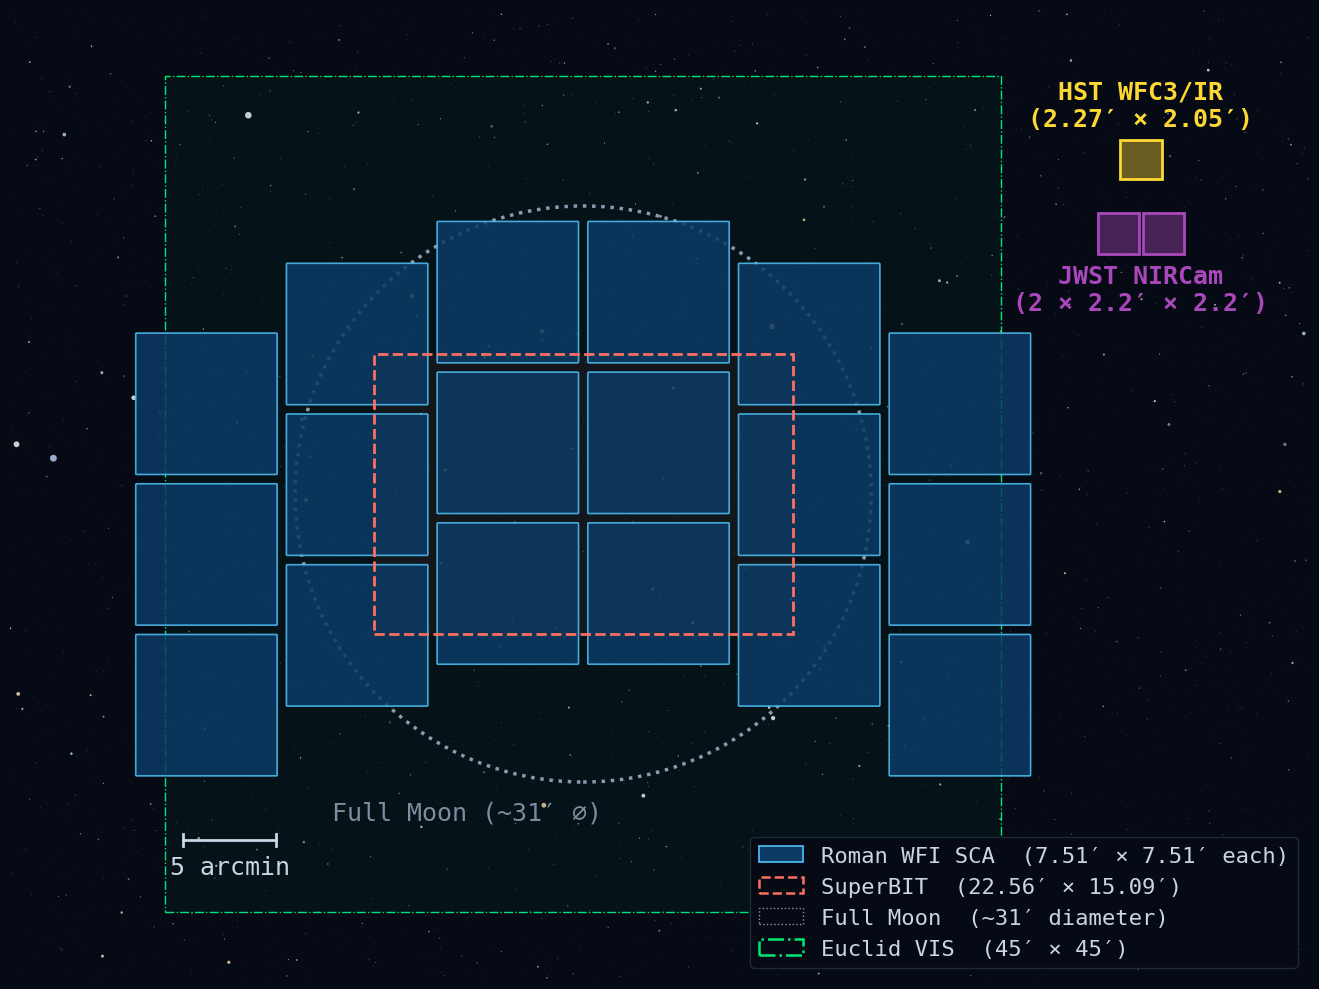

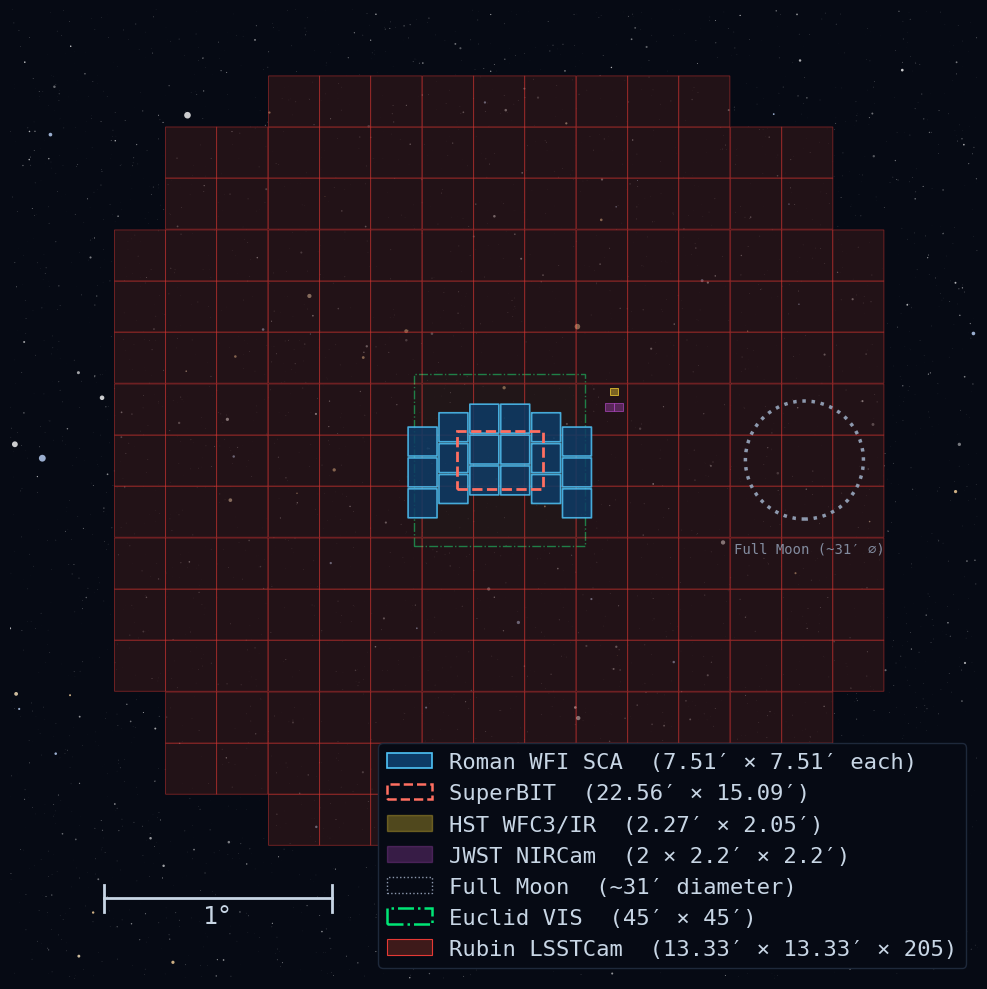

In [ ]:
fig, ax = plot_footprint(save_path="footprint_1.png", dpi=200)
fig, ax = plot_footprint_with_lsst(save_path="footprint_2.png", dpi=200)
